# Avellaneda-Stoikov Strategy

## Strategy setup

In [1]:
import sys
import math
import numpy as np
from pathlib import Path
import pandas as pd
import os
import itertools
from tqdm.notebook import tqdm


ROOT = next(p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents) if (p / ".git").exists())

for path in (str(ROOT), str(ROOT / "research")):
    if path not in sys.path:
        sys.path.insert(0, path)

from tools import ROOT   # override ROOT with the repo path from tools/__init__.py
from backtesting.lighter import Strategy, Backtester, OrderBook, LighterFeed
from backtesting.lighter.instruments.visualize import BacktestResult

CAPITAL = 2000.0  # USD

In [2]:
os.makedirs("results", exist_ok=True)


def grid_search(strategy_cls, param_grid, backtester, feed, fixed_params=None, capital=CAPITAL):
    """Grid search over `param_grid`.

    Each row = the parameter combo + EVERY numeric metric from
    ``BacktestResult(prefix, capital).summary()`` — pulled as one dict merge,
    not a hand-picked list, so new metrics (capture_yield, net_edge, jumps, …)
    show up in the frame automatically. Returns a tidy DataFrame (params first).
    """
    fixed_params = fixed_params or {}
    keys   = list(param_grid.keys())
    combos = list(itertools.product(*param_grid.values()))
    rows   = []

    for combo in tqdm(combos, desc="grid_search"):
        params = dict(zip(keys, combo)) | fixed_params
        prefix = f"/tmp/_gs_{abs(hash(str(sorted(params.items()))))}"
        backtester.run(strategy_cls(**params), feed, output_path=prefix)

        metrics = BacktestResult(prefix, capital=capital).summary()
        rows.append({**params, **metrics})          # params first, then all metrics

        for suffix in ("_pnl", "_quotes", "_fills"):
            try: os.remove(f"{prefix}{suffix}.csv")
            except: pass

    return pd.DataFrame(rows)

In [3]:
class AvellanedaStoikov(Strategy):
    def __init__(self, sigma, kappa, gamma, T, Q):
        self.gamma   = gamma
        self.T       = T
        self._sigma2 = sigma ** 2
        self.Q = Q
        self._half_log_term = (1.0 / gamma) * math.log(1.0 + gamma / kappa)
        self._t0_us  = None

    def on_lob(self, ob: OrderBook, inventory: float):
        if self._t0_us is None:
            self._t0_us = ob.timestamp_us
        tau = max(0.0, self.T - ((ob.timestamp_us - self._t0_us) / 1e6 % self.T))

        risk_term   = self.gamma * self._sigma2 * tau
        r           = ob.mid - inventory * risk_term
        half_spread = 0.5 * risk_term + self._half_log_term
        return [
            ("bid", r - half_spread, self.Q),
            ("ask", r + half_spread, self.Q),
        ]

In [4]:
days = range(13, 24)          # Jul 13–23
hours = range(0, 24)

lob_paths = []
trades_paths = []

for d in days:
    day_str = f"202607{d:02d}"
    for h in hours:
        lob_paths.append(ROOT / f"data/lighter/TAO/lob/{day_str}/{h:02d}.parquet")
        trades_paths.append(ROOT / f"data/lighter/TAO/trades/{day_str}/{h:02d}.jsonl.zst")

print(f"LOB files:    {len(lob_paths)}")
print(f"Trades files: {len(trades_paths)}")

LOB files:    264
Trades files: 264


In [5]:
feed = LighterFeed(lob_paths, trades_paths)
feed

LighterFeed(depth=3, lob=6,716,540 snapshots [2026-07-13 00:00:00.043000 → 2026-07-23 23:59:59.911000], trades=16,102 [2026-07-12 23:10:32.212000 → 2026-07-23 23:59:13.924000])

In [6]:
# Calibrate AS inputs straight from the loaded feed (arrays, not CSV).
mid    = (feed.bid_px[:, 0] + feed.ask_px[:, 0]) / 2.0
mid_ts = pd.to_datetime(feed.lob_ts, unit="us")
tr_ts  = pd.to_datetime(feed.trade_ts, unit="us")

# sigma — std of 1-sec mid increments (price / sqrt-sec)
mid_1s    = pd.Series(mid, index=mid_ts).resample("1s").last().ffill()
sigma_hat = float(mid_1s.diff().dropna().std())

# A — mean trade arrival rate (trades / sec)
span_sec = (tr_ts.max() - tr_ts.min()).total_seconds()
A_hat    = len(feed.trade_ts) / span_sec

# kappa — exp decay from mean |trade_price - mid|; mid aligned to each trade (backward)
aligned = pd.merge_asof(
    pd.DataFrame({"price": feed.trade_price}, index=tr_ts).sort_index(),
    pd.DataFrame({"mid": mid}, index=mid_ts).sort_index(),
    left_index=True, right_index=True, direction="backward",
).dropna()
delta     = (aligned["price"] - aligned["mid"]).abs()
kappa_hat = 1.0 / float(delta[delta > 0].mean())

print(f"sigma = {sigma_hat:.3e}   (mid volatility, price / sqrt-sec)")
print(f"A     = {A_hat:.5f}   (mean trade arrival rate, trades/sec)")
print(f"kappa = {kappa_hat:.3e}   (exp decay rate; mean |trade - mid| = {1/kappa_hat:.3e})")

sigma = 1.969e-02   (mid volatility, price / sqrt-sec)
A     = 0.01689   (mean trade arrival rate, trades/sec)
kappa = 2.404e+01   (exp decay rate; mean |trade - mid| = 4.160e-02)


In [7]:
def check_feed(f):
    assert f.lob_ts.dtype == np.int64 and f.trade_ts.dtype == np.int64
    assert f.bid_px.shape[1] == f.ask_px.shape[1], "level count mismatch"
    assert (np.diff(f.lob_ts)   >= 0).all(), "LOB timestamps not sorted"
    assert (np.diff(f.trade_ts) >= 0).all(), "trade timestamps not sorted"
    assert set(np.unique(f.trade_is_sell)).issubset({0, 1})

    best_bid, best_ask = f.bid_px[:, 0], f.ask_px[:, 0]
    crossed = int((best_ask <= best_bid).sum())
    print(f"levels        : {f.bid_px.shape[1]}")
    print(f"lob snapshots : {len(f.lob_ts):,}  (crossed/locked: {crossed})")
    print(f"trades        : {len(f.trade_ts):,}  (sells: {int(f.trade_is_sell.sum()):,})")
    print("invariants OK")

check_feed(feed)

levels        : 3
lob snapshots : 6,716,540  (crossed/locked: 0)
trades        : 16,102  (sells: 8,349)
invariants OK


In [8]:
bt = Backtester(quote_log_stride=1, log_interval_sec=1.0)

sweep = grid_search(
    AvellanedaStoikov,
    {
        "sigma": [2.355e-2],
        "kappa": [2.306e+1],
        "gamma": [0.02, 0.05],
        "T":     [600, 2000],
        "Q":     [0.01, 0.1, 1],
    },
    bt,
    feed,
)

grid_search:   0%|          | 0/12 [00:00<?, ?it/s]

In [9]:
sweep.columns

Index(['sigma', 'kappa', 'gamma', 'T', 'Q', 'total_pnl', 'n_days',
       'sharpe_annualized', 'max_drawdown', 'spread_capture_usd',
       'inv_mtm_usd', 'identity_gap_usd', 'inv_mtm_grid_error_usd',
       'spread_capture_pct', 'inv_mtm_pct', 'net_edge_per_fill_bps',
       'markout_30s_bps', 'net_edge_ci_lo', 'net_edge_ci_hi',
       'capture_share_of_variance', 'corr_hourly_pnl_return', 'n_fills',
       'n_bid_fills', 'n_ask_fills', 'fill_imbalance', 'turnover',
       'turnover_usd', 'capture_yield_bps', 'avg_inventory', 'std_inventory',
       'max_abs_inventory', 'mean_abs_inventory', 'p90_abs_inventory',
       'time_at_90pct_max_inv_pct', 'median_excursion_min',
       'zero_crossings_per_day', 'worst_unrealized_usd', 'n_jumps',
       'pnl_in_jump_windows_usd', 'pnl_in_jump_windows_pct', 'worst_hour_usd',
       'p5_hourly_usd', 'two_sided_uptime_pct', 'quote_updates_min_p50',
       'quote_updates_min_p95', 'median_quote_interval_s',
       'median_pnl_interval_s'],
      d

In [10]:
sweep.sort_values("sharpe_annualized", ascending=False)[
    ["total_pnl", "spread_capture_usd", "sharpe_annualized", "max_drawdown", 
     "net_edge_ci_lo", "corr_hourly_pnl_return", "n_fills", "turnover_usd", 
     "avg_inventory", "max_abs_inventory", "mean_abs_inventory",
     "pnl_in_jump_windows_usd", "worst_hour_usd", "capture_yield_bps"
    ]
].head(15)

,total_pnl,spread_capture_usd,sharpe_annualized,max_drawdown,net_edge_ci_lo,corr_hourly_pnl_return,n_fills,turnover_usd,avg_inventory,max_abs_inventory,mean_abs_inventory,pnl_in_jump_windows_usd,worst_hour_usd,capture_yield_bps
9,7.208591,0.972133,9.194461,-3.415137,1.340131,-0.252425,2147,4028.995514,-0.026025,0.756,0.165018,2.257906,-1.090732,2.412843
10,15.786231,7.461467,8.885865,-5.343931,1.120365,-0.019385,2097,34079.158617,-0.021756,3.101,0.351764,2.619731,-3.419747,2.189452
4,26.198173,9.183433,7.436011,-13.295361,1.134569,-0.040964,2840,45317.272094,-0.005137,4.999,0.742743,4.985290,-7.711154,2.026475
1,43.617662,10.637117,5.945486,-33.718931,0.981002,-0.063144,3363,53338.088155,0.258270,7.468,1.563992,5.590018,-8.481376,1.994282
2,60.090713,52.386691,5.723103,-40.208682,0.699382,0.073270,3541,301100.652214,0.180846,23.480,2.034135,-1.614117,-17.700421,1.739840
7,22.871360,9.352036,5.714264,-16.340478,0.886608,-0.040576,2922,46608.588565,0.066949,5.507,0.814234,-1.095248,-4.247672,2.006505
5,29.090049,45.216143,5.544754,-21.653550,0.733891,-0.024976,3009,262663.903402,-0.043970,13.089,0.971149,8.062603,-7.972394,1.721445
8,30.051475,44.200400,4.817418,-22.430329,0.517566,0.018700,3196,279836.278336,0.018984,20.626,1.183596,0.973826,-16.146577,1.579509
3,7.328149,1.212671,4.171155,-8.524080,1.334573,-0.204873,2960,5500.263137,-0.012070,1.219,0.391294,3.115909,-2.637853,2.204751
11,11.217479,34.917115,3.460066,-12.523693,0.180581,-0.044753,2291,215701.837552,0.008681,7.026,0.545685,4.062530,-3.834891,1.618768


## Strategy selection

In [11]:
def filter_stage(df, conditions, stage, show=None):
    """Apply one tier of drop-rules to `df` and report what was cut and why.

    conditions : list of (reason, is_bad), where is_bad(df) -> boolean Series with
                 True = row VIOLATES the rule (NaN in a checked cell counts as bad).
    Each dropped row is charged to the FIRST rule it fails, so the per-rule counts
    partition the total dropped. Returns the survivors (a copy).
    show : extra metric columns to include in the drop-log (params are always shown).
    """
    param_cols = [c for c in ("sigma", "kappa", "gamma", "T", "Q", "n_levels", "step")
                  if c in df.columns]
    reason = pd.Series(index=df.index, dtype=object)
    alive = pd.Series(True, index=df.index)

    print(f"── stage {stage}:  {len(df)} in")
    for label, is_bad in conditions:
        bad = is_bad(df).fillna(True)          # NaN in a checked column → drop
        newly = bad & alive                     # rows still alive that this rule kills
        reason[newly] = label
        alive &= ~bad
        print(f"   −{int(newly.sum()):<4} {label}")

    kept = df[alive].copy()
    dropped = df[~alive].assign(drop_reason=reason[~alive])
    print(f"── stage {stage}:  {len(kept)} out   ({len(dropped)} dropped)")
    if len(dropped):
        display(dropped[param_cols + list(show or []) + ["drop_reason"]])
    return kept

### Tier 1: validity check

In [12]:
GRID_ERR_FLOOR_BPS = 1.0     # grid_error floor as bps of turnover (scale-aware); below this = negligible
MAX_LOG_INTERVAL_S = 1.5     # coarse-log gate: median quote/pnl log interval above this => grid undersampled


def coarse_log(d):
    """Direct coarse-log detector — the real insurance now that grid_error is fill-aware
    (~0 for any run) and can no longer flag undersampling. Needs the median-interval
    columns (summary() exposes them); if absent, warn and skip."""
    if "median_quote_interval_s" not in d.columns:
        print("   ⚠ no median-interval columns: coarse-log detector skipped (re-run sweep)")
        return pd.Series(False, index=d.index)
    return (d["median_quote_interval_s"] > MAX_LOG_INTERVAL_S) | (d["median_pnl_interval_s"] > MAX_LOG_INTERVAL_S)


stage_1 = [
    ("identity_gap: |gap| > max($0.05, 0.1%·|pnl|) -> accounting diverges, all numbers suspect",
     lambda d: d["identity_gap_usd"].abs() > np.maximum(0.05, 0.001 * d["total_pnl"].abs())),

    # grid_error is now fill-aware (~0 for any run); kept as redundant safety on attribution.
    ("grid_error: |err| > max(GRID_ERR_FLOOR_BPS·turnover·1e-4, 15%·max(|inv_mtm|,|pnl|)) -> attribution off",
     lambda d: d["inv_mtm_grid_error_usd"].abs() > np.maximum(
         GRID_ERR_FLOOR_BPS * d["turnover_usd"] * 1e-4,
         0.15 * np.maximum(d["inv_mtm_usd"].abs(), d["total_pnl"].abs()))),

    ("coarse log: median quote/pnl interval > 1.5s -> grid metrics (jumps/uptime/variance) undersampled",
     coarse_log),

    ("n_fills < 30 -> neither CI nor markout is meaningful (NaN in key columns lands here too)",
     lambda d: d["n_fills"] < 30),

    ("broken run: uptime not in [0,100] | drawdown>0 | turnover<0 | total_pnl=NaN",
     lambda d: (d["two_sided_uptime_pct"] < 0) | (d["two_sided_uptime_pct"] > 100)
               | (d["max_drawdown"] > 0) | (d["turnover_usd"] < 0) | d["total_pnl"].isna()),
]

sweep_stage_1 = filter_stage(sweep, stage_1, 1, show=[
    "total_pnl", "identity_gap_usd", "inv_mtm_usd", "inv_mtm_grid_error_usd",
    "median_quote_interval_s", "median_pnl_interval_s",
    "n_fills", "two_sided_uptime_pct", "max_drawdown", "turnover_usd"])

── stage 1:  12 in
   −0    identity_gap: |gap| > max($0.05, 0.1%·|pnl|) -> accounting diverges, all numbers suspect
   −0    grid_error: |err| > max(GRID_ERR_FLOOR_BPS·turnover·1e-4, 15%·max(|inv_mtm|,|pnl|)) -> attribution off
   −0    coarse log: median quote/pnl interval > 1.5s -> grid metrics (jumps/uptime/variance) undersampled
   −0    n_fills < 30 -> neither CI nor markout is meaningful (NaN in key columns lands here too)
   −0    broken run: uptime not in [0,100] | drawdown>0 | turnover<0 | total_pnl=NaN
── stage 1:  12 out   (0 dropped)


### Tier B: structure check

- **`economically_negligible`** — `turnover/day < $1000` **or** `fills/day < 30`
- **`net_edge_ci_hi < 0`**
- **`markout_30s < −3.5 bps` with `net_edge_per_fill < 0`**
- **`|fill_imbalance| > 0.6`**
- **`time@≥90% max|inv| > 45%` together with `zero_crossings/day < 0.5`**

In [13]:
# Tier B — structurally dead (independent of calibration): traits no re-tuning fixes.
# Deliberately conservative — a "death sentence" only for the unambiguously broken.
# Rows here already survived Tier 1, so metrics are present; NaN in a checked column -> dropped.
MARKOUT_DEATH_BPS    = -3.5     # markout_30s below this (with negative edge) = under informed flow
IMBALANCE_MAX        = 0.6      # |fill_imbalance| above this = one-sided sponge, not making
PINNED_TIME_PCT      = 45.0     # time at >=90% max|inv| above this ...
PINNED_XINGS_DAY     = 0.5      # ... together with fewer than this many sign flips/day = held bet
MIN_TURNOVER_PER_DAY = 1000.0   # economic-scale floor: notional $/day ...
MIN_FILLS_PER_DAY    = 30       # ... and fills/day (per-fill bps are blind to scale)


def econ_negligible(d):
    """DEAD if daily turnover or daily fills fall below the economic-scale floor.
    A strategy doing $400/day can have perfect per-fill bps yet be economically empty
    and statistically unverifiable live — bps metrics are normalised per fill and don't
    see scale. Needs n_days; if the column is absent, warn (no_n_days) and skip — don't
    fabricate it from the index."""
    if "n_days" not in d.columns:
        print("   ⚠ no_n_days: economically_negligible skipped (n_days column absent)")
        return pd.Series(False, index=d.index)
    nd = d["n_days"].where(d["n_days"] > 0, np.nan)
    return (d["turnover_usd"] / nd < MIN_TURNOVER_PER_DAY) | (d["n_fills"] / nd < MIN_FILLS_PER_DAY)


stage_b = [
    (f"economically_negligible: turnover/day < ${MIN_TURNOVER_PER_DAY:.0f} or fills/day < {MIN_FILLS_PER_DAY}"
     " -> empty at scale, live-unverifiable",
     econ_negligible),

    ("dead unit-economics: net_edge_ci_hi < 0 (even the UPPER CI bound is negative -> losing, significant)",
     lambda d: d["net_edge_ci_hi"] < 0),

    (f"under informed flow: markout_30s < {MARKOUT_DEATH_BPS} bps AND net_edge_per_fill < 0",
     lambda d: (d["markout_30s_bps"] < MARKOUT_DEATH_BPS) & (d["net_edge_per_fill_bps"] < 0)),

    (f"one-sided sponge: |fill_imbalance| > {IMBALANCE_MAX} (accumulating a position, not making)",
     lambda d: d["fill_imbalance"].abs() > IMBALANCE_MAX),

    (f"pinned inventory: time@>=90%max|inv| > {PINNED_TIME_PCT}% AND zero_crossings/day < {PINNED_XINGS_DAY}",
     lambda d: (d["time_at_90pct_max_inv_pct"] > PINNED_TIME_PCT)
               & (d["zero_crossings_per_day"] < PINNED_XINGS_DAY)),
]

sweep_stage_2 = filter_stage(sweep_stage_1, stage_b, 2, show=[
    "turnover_usd", "n_fills", "n_days", "net_edge_ci_hi", "markout_30s_bps",
    "net_edge_per_fill_bps", "fill_imbalance", "time_at_90pct_max_inv_pct", "zero_crossings_per_day"])

── stage 2:  12 in
   −4    economically_negligible: turnover/day < $1000 or fills/day < 30 -> empty at scale, live-unverifiable
   −0    dead unit-economics: net_edge_ci_hi < 0 (even the UPPER CI bound is negative -> losing, significant)
   −0    under informed flow: markout_30s < -3.5 bps AND net_edge_per_fill < 0
   −0    one-sided sponge: |fill_imbalance| > 0.6 (accumulating a position, not making)
   −0    pinned inventory: time@>=90%max|inv| > 45.0% AND zero_crossings/day < 0.5
── stage 2:  8 out   (4 dropped)


,sigma,kappa,gamma,T,Q,turnover_usd,n_fills,n_days,net_edge_ci_hi,markout_30s_bps,net_edge_per_fill_bps,fill_imbalance,time_at_90pct_max_inv_pct,zero_crossings_per_day,drop_reason
0,0.02355,23.06,0.02,600,0.01,6482.844458,3519,10.999988,1.868060,-0.608053,1.483560,0.063939,2.925505,0.909092,economically_negligible: turnover/day < $1000 ...
3,0.02355,23.06,0.02,2000,0.01,5500.263137,2960,10.999988,2.177393,-0.448124,1.765556,0.039865,2.318497,1.818184,economically_negligible: turnover/day < $1000 ...
6,0.02355,23.06,0.05,600,0.01,5753.450946,3105,10.999988,1.981489,-0.586585,1.596229,0.047343,2.355114,1.090910,economically_negligible: turnover/day < $1000 ...
9,0.02355,23.06,0.05,2000,0.01,4028.995514,2147,10.999988,2.403967,-0.553456,1.861353,0.031206,0.121317,2.090911,economically_negligible: turnover/day < $1000 ...


### Tier C: flags and interpretation

- **`directional_bet`** — `|corr(hourly_pnl, hourly_return)| > 0.3`: PnL tracks the hourly move, not the spread.
- **`storm_driven`** — `|pnl_in_jump_windows_%| > 60%`: the result was made in jump windows → fragile.
- **`inventory_lottery`** — `capture_share_of_variance < 0.1` **and** `inv_mtm_% > 90%`: PnL is a pure inventory lottery.
- **`variance_share_suspect`** — `capture_share_of_variance > 0.8` **and** `inv_mtm_% > 70%`: chop that
  makes >70% of PnL usually dominates variance too, so "80% of variance from capture" is mathematically
  tense and historically flagged a grid artifact in the corr calc → verify the column by hand. (Not the
  same region as `inventory_lottery` — the opposite extreme.)
- **`unquotable`** — `quote_updates/min p95 > venue limit` (40–60): not runnable on Standard as-is.
- **`deep_pain`** — `|worst_unrealized| > ~4× |total_pnl|`: tolerated multiples of what it earned.

In [14]:
def flag_stage(df, flags, stage):
    """Annotate rows with the flags they trip — nothing is dropped (Tier C).

    Companion to filter_stage: same (name, predicate) shape, but rows PASS THROUGH
    and each raised flag is recorded. flags = list of (name, is_flagged), where
    is_flagged(df) -> boolean Series, True = row raises `name`. NaN in a checked
    cell -> NOT flagged (a warning you can't compute isn't raised — the opposite of
    filter_stage, which drops on NaN).

    Adds a boolean column per flag (`flag_<name>`), a `flags` verdict string and
    `n_flags`. Prints per-flag counts. Returns a copy with all rows.
    """
    out = df.copy()
    hits = {}
    print(f"── stage {stage} (flags, no drops):  {len(out)} rows")
    for name, is_flagged in flags:
        h = is_flagged(df).fillna(False)
        hits[name] = h.to_numpy()
        out[f"flag_{name}"] = h
        print(f"   ⚑ {int(h.sum()):<4} {name}")

    hit_df = pd.DataFrame(hits, index=out.index)
    out["flags"]   = hit_df.apply(lambda r: ", ".join(hit_df.columns[r.values]), axis=1)
    out["n_flags"] = hit_df.sum(axis=1).astype(int)
    print(f"── stage {stage}:  {int((out['n_flags'] > 0).sum())}/{len(out)} flagged, "
          f"{int((out['n_flags'] == 0).sum())} clean")
    return out

In [15]:
# Tier C — alive but flagged: everything passes; flags go into the verdict for later stages.
# NaN in a checked column -> NOT flagged (unlike the drop tiers). Thresholds are tunable knobs.
QUOTE_RATE_LIMIT = 50       # venue max quote updates/min on Standard (40–60); p95 above it = unquotable
PAIN_MULT        = 4.0      # |worst_unrealized| beyond this × |total_pnl| = tolerated multiples of PnL
VS_HIGH          = 0.8      # capture_share_of_variance above this ...
MTM_DOMINANT     = 70       # ... together with inv_mtm_% above this = tense combo (likely grid artifact)

stage_c = [
    ("directional_bet",     # PnL tracks the hourly move, not the spread (config, not family)
     lambda d: d["corr_hourly_pnl_return"].abs() > 0.3),

    ("storm_driven",        # result made inside jump windows -> fragile
     lambda d: d["pnl_in_jump_windows_pct"].abs() > 60),

    ("inventory_lottery",   # variance not from capture AND PnL almost all inventory MtM
     lambda d: (d["capture_share_of_variance"] < 0.1) & (d["inv_mtm_pct"] > 90)),

    ("variance_share_suspect",  # >80% variance "from capture" yet >70% PnL from mtm -> mathematically
     lambda d: (d["capture_share_of_variance"] > VS_HIGH) & (d["inv_mtm_pct"] > MTM_DOMINANT)),  # tense; historically a grid-corr artifact -> verify the column by hand

    ("unquotable",          # quote rate above the venue limit -> not runnable as-is
     lambda d: d["quote_updates_min_p95"] > QUOTE_RATE_LIMIT),

    ("deep_pain",           # tolerated multiples of what it earned
     lambda d: d["worst_unrealized_usd"].abs() > PAIN_MULT * d["total_pnl"].abs()),
]

sweep_stage_3 = flag_stage(sweep_stage_2, stage_c, 3)

view = [c for c in ("sigma", "kappa", "gamma", "T", "Q") if c in sweep_stage_3.columns]
view += ["total_pnl", "corr_hourly_pnl_return", "pnl_in_jump_windows_pct",
         "capture_share_of_variance", "inv_mtm_pct", "quote_updates_min_p95",
         "worst_unrealized_usd", "flags", "n_flags"]
sweep_stage_3[view]

── stage 3 (flags, no drops):  8 rows
   ⚑ 0    directional_bet
   ⚑ 0    storm_driven
   ⚑ 0    inventory_lottery
   ⚑ 0    variance_share_suspect
   ⚑ 8    unquotable
   ⚑ 0    deep_pain
── stage 3:  8/8 flagged, 0 clean


,sigma,kappa,gamma,T,Q,total_pnl,corr_hourly_pnl_return,pnl_in_jump_windows_pct,capture_share_of_variance,inv_mtm_pct,quote_updates_min_p95,worst_unrealized_usd,flags,n_flags
1,0.02355,23.06,0.02,600,0.1,43.617662,-0.063144,12.815952,0.649556,75.612822,656.0,-15.839859,unquotable,1
2,0.02355,23.06,0.02,600,1.0,60.090713,0.073270,-2.686134,0.588511,12.820654,656.0,-16.982184,unquotable,1
4,0.02355,23.06,0.02,2000,0.1,26.198173,-0.040964,19.029153,0.620291,64.946284,656.0,-8.837012,unquotable,1
5,0.02355,23.06,0.02,2000,1.0,29.090049,-0.024976,27.716019,0.557552,-55.435089,656.0,-9.583097,unquotable,1
7,0.02355,23.06,0.05,600,0.1,22.871360,-0.040576,-4.788732,0.628572,59.110274,656.0,-7.380891,unquotable,1
8,0.02355,23.06,0.05,600,1.0,30.051475,0.018700,3.240528,0.597785,-47.082297,656.0,-14.364412,unquotable,1
10,0.02355,23.06,0.05,2000,0.1,15.786231,-0.019385,16.595038,0.601542,52.734337,656.0,-3.215402,unquotable,1
11,0.02355,23.06,0.05,2000,1.0,11.217479,-0.044753,36.216066,0.580514,-211.274162,656.0,-5.820798,unquotable,1


### Verification

Runs on one **dense** backtest (`quote_log_stride=1, log_interval_sec=1.0`) so the 1s grid isn't
undersampled. **(a)** build `d_pnl` and `d_mtm = inventory·Δmid` on the grid, scatter + corr; **(b)**
recompute `1 − corr²` by hand and assert it equals the summary column (same grid, same formula);
**(c)** run the formula on synthetics with known answers — pure drift (capture = 0) must give ~0, pure
capture at a still mid must give ~1. A mismatch in (b) or a fail in (c) → escalate with numbers; the
column is untrustworthy in past runs until fixed. Prime suspect: series misalignment on the grid (as-of
lags of `pnl.csv` vs `quotes.csv`) — that produced the `0.993` seen on a coarse log.

corr(d_pnl, d_mtm)         = +0.5920
(b) 1 - corr^2 (manual)    = +0.6496
    capture_share (column) = +0.6496
    |manual - column|      = 0.00e+00
    inv_mtm_grid_error     = +7.11e-15   (fill-aware -> ~0)


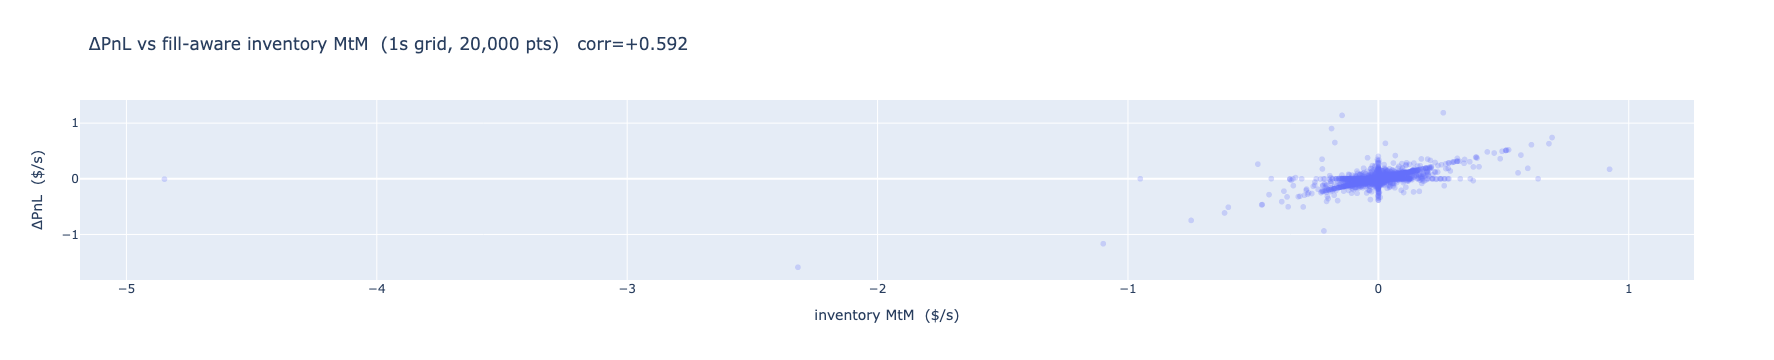

In [16]:
# One dense backtest (stride=1, log_interval=1s) so the 1s grid isn't undersampled.
# (Any strategy works — this checks the formula, not a specific config.)
v_params = dict(sigma=2.355e-2, kappa=2.306e+1, gamma=0.02, T=600.0, Q=0.1)
v_prefix = "/tmp/_vcap"
Backtester(quote_log_stride=1, log_interval_sec=1.0).run(
    AvellanedaStoikov(**v_params), feed=feed, output_path=v_prefix)
rv = BacktestResult(v_prefix, capital=CAPITAL)

# (a) two 1s-grid series: d_pnl and the fill-aware d_mtm (exact within-second attribution)
g = rv._grid()
pair = pd.concat([g["pnl"].diff().rename("d_pnl"),
                  rv._grid_mtm().rename("d_mtm")], axis=1).dropna()
corr   = float(pair["d_pnl"].corr(pair["d_mtm"]))
manual = 1.0 - corr ** 2
column = rv.summary()["capture_share_of_variance"]

# (b) manual 1 - corr^2 must equal the summary column (same grid, same fill-aware d_mtm)
print(f"corr(d_pnl, d_mtm)         = {corr:+.4f}")
print(f"(b) 1 - corr^2 (manual)    = {manual:+.4f}")
print(f"    capture_share (column) = {column:+.4f}")
print(f"    |manual - column|      = {abs(manual - column):.2e}")
assert abs(manual - column) < 1e-9, "MISMATCH: column != 1 - corr^2 on the same grid -> escalate"

# grid inv_mtm is now fill-aware -> its total must match the exact checkpoint decomposition
print(f"    inv_mtm_grid_error     = {rv.summary()['inv_mtm_grid_error_usd']:+.2e}   (fill-aware -> ~0)")

import plotly.express as px
sample = pair.sample(min(len(pair), 20000), random_state=0)
px.scatter(sample, x="d_mtm", y="d_pnl", opacity=0.25,
           title=f"ΔPnL vs fill-aware inventory MtM  (1s grid, {len(sample):,} pts)   corr={corr:+.3f}",
           labels={"d_mtm": "inventory MtM  ($/s)", "d_pnl": "ΔPnL  ($/s)"}).show()

In [17]:
# (c) run the exact formula on synthetics with known answers.
def capture_share(d_pnl, d_mtm):
    """The exact expression from result.py._compute (1 - corr^2, with the same guards)."""
    p = pd.concat([pd.Series(d_pnl), pd.Series(d_mtm)], axis=1).dropna()
    if len(p) >= 2 and p.iloc[:, 0].std() > 0 and p.iloc[:, 1].std() > 0:
        r = p.iloc[:, 0].corr(p.iloc[:, 1])
        return 1.0 - r * r
    return np.nan

rng = np.random.default_rng(0)
n = 5000

# c1) pure drift: PnL is entirely inventory MtM, capture = 0  ->  expect ~0
inv  = np.cumsum(rng.normal(0, 1.0, n))
dmid = rng.normal(0, 1e-3, n)
d_mtm1 = inv * dmid
d_pnl1 = d_mtm1.copy()                       # no capture -> PnL == inventory MtM
print(f"(c1) pure drift        capture_share = {capture_share(d_pnl1, d_mtm1):.4f}   (expect ~0)")

# c2) pure capture at ~motionless mid: inventory MtM ~ 0, PnL is capture noise  ->  expect ~1
d_pnl2 = rng.normal(0, 1e-2, n)              # capture noise only
d_mtm2 = rng.normal(0, 1e-9, n)             # infinitesimal, independent mid jitter (real mid always moves)
print(f"(c2) pure capture      capture_share = {capture_share(d_pnl2, d_mtm2):.4f}   (expect ~1)")
print(f"     exact-static mid   capture_share = {capture_share(d_pnl2, np.zeros(n))}   "
      "(NaN: corr with a constant is 0/0 — benign, real mid never sits exactly still)")

(c1) pure drift        capture_share = 0.0000   (expect ~0)
(c2) pure capture      capture_share = 0.9999   (expect ~1)
     exact-static mid   capture_share = nan   (NaN: corr with a constant is 0/0 — benign, real mid never sits exactly still)


In [18]:
sweep_stage_2

,sigma,kappa,gamma,T,Q,total_pnl,n_days,sharpe_annualized,max_drawdown,spread_capture_usd,...,n_jumps,pnl_in_jump_windows_usd,pnl_in_jump_windows_pct,worst_hour_usd,p5_hourly_usd,two_sided_uptime_pct,quote_updates_min_p50,quote_updates_min_p95,median_quote_interval_s,median_pnl_interval_s
1,0.02355,23.06,0.02,600,0.1,43.617662,10.999988,5.945486,-33.718931,10.637117,...,88,5.590018,12.815952,-8.481376,-2.882506,99.978220,417.0,656.0,0.054,1.095
2,0.02355,23.06,0.02,600,1.0,60.090713,10.999988,5.723103,-40.208682,52.386691,...,88,-1.614117,-2.686134,-17.700421,-4.324431,99.993266,417.0,656.0,0.054,1.095
4,0.02355,23.06,0.02,2000,0.1,26.198173,10.999988,7.436011,-13.295361,9.183433,...,88,4.985290,19.029153,-7.711154,-1.655549,99.982008,417.0,656.0,0.054,1.095
5,0.02355,23.06,0.02,2000,1.0,29.090049,10.999988,5.544754,-21.653550,45.216143,...,88,8.062603,27.716019,-7.972394,-2.191809,99.994529,417.0,656.0,0.054,1.095
7,0.02355,23.06,0.05,600,0.1,22.871360,10.999988,5.714264,-16.340478,9.352036,...,88,-1.095248,-4.788732,-4.247672,-1.596223,99.980745,417.0,656.0,0.054,1.095
8,0.02355,23.06,0.05,600,1.0,30.051475,10.999988,4.817418,-22.430329,44.200400,...,88,0.973826,3.240528,-16.146577,-2.188850,99.994108,417.0,656.0,0.054,1.095
10,0.02355,23.06,0.05,2000,0.1,15.786231,10.999988,8.885865,-5.343931,7.461467,...,88,2.619731,16.595038,-3.419747,-0.756389,99.987058,417.0,656.0,0.054,1.095
11,0.02355,23.06,0.05,2000,1.0,11.217479,10.999988,3.460066,-12.523693,34.917115,...,88,4.062530,36.216066,-3.834891,-1.380294,99.995370,417.0,656.0,0.054,1.095


In [19]:
best = sweep_stage_2.sort_values("sharpe_annualized", ascending=False).iloc[0]
best_params = {k: best[k] for k in ["sigma", "kappa", "gamma", "T", "Q"]}
print("Best params:", best_params)

Best params: {'sigma': np.float64(0.02355), 'kappa': np.float64(23.06), 'gamma': np.float64(0.05), 'T': np.float64(2000.0), 'Q': np.float64(0.1)}


In [20]:
params = best_params
# params = {'sigma': np.float64(0.02355), 'kappa': np.float64(23.06), 'gamma': np.float64(0.02), 'T': np.float64(600.0), 'Q': np.float64(0.1)}
prefix = "/tmp/_lighter_dod"

bt = Backtester(quote_log_stride=1, log_interval_sec=1.0)
bt.run(AvellanedaStoikov(**params), feed=feed, output_path=prefix)

'/tmp/_lighter_dod'

In [21]:
s = BacktestResult(prefix, capital=CAPITAL)
display(s.summary_df())

value  \
group     metric                                               
PnL       total_pnl ($)                             +15.7862   
          sharpe_annualized                            +8.89   
          max_drawdown ($)                           -5.3439   
          spread_capture ($)                         +7.4615   
          spread_capture (% of total)                +47.27%   
          capture_yield (bps)                          +2.19   
          inventory_mtm ($)                          +8.3248   
          inventory_mtm (% of total)                 +52.73%   
          identity_gap ($)                           -0.0000   
          inv_mtm_grid_error ($)                     -0.0000   
          net_edge_per_fill (bps)                      +1.57   
          net_edge CI95 [lo, hi]              [+1.12, +2.02]   
          markout_30s (bps)                            -0.65   
          capture_share_of_variance                  +0.6015   
          corr(hourly_pnl, hourly_return)            -0.0194   
Fills     n_fills                                      2,097   
          n_bid_fills                                  1,062   
          n_ask_fills                                  1,035   
          fill_imbalance                             +0.0129   
Inventory avg_inventory                              -0.0218   
          std_inventory                               0.5105   
          max_abs_inventory                           3.1010   
          turnover ($)                            +34,079.16   
          mean |inv|                                  0.3518   
          p90 |inv|                                   0.7320   
          zero_crossings / day                        7.3636   
          median_excursion (min)                    258.4667   
          worst_unrealized ($)                       -3.2154   
          time at ≥90% max|inv| (%)                     0.03   
Tails     n_jumps                                         88   
          pnl_in_jump_windows ($)                    +2.6197   
          pnl_in_jump_windows (% of |total|)         +16.60%   
          worst_hour ($)                             -3.4197   
          p5_hourly ($)                              -0.7564   
Ops       two_sided_uptime (%)                         99.99   
          quote_updates/min p50                       417.00   
          quote_updates/min p95                       656.00   

                                                                           note  
group     metric                                                                 
PnL       total_pnl ($)                                                          
          sharpe_annualized                                                      
          max_drawdown ($)                                                       
          spread_capture ($)                                                     
          spread_capture (% of total)                                            
          capture_yield (bps)                                                    
          inventory_mtm ($)                                                      
          inventory_mtm (% of total)                                             
          identity_gap ($)                                                       
          inv_mtm_grid_error ($)                                                 
          net_edge_per_fill (bps)                                                
          net_edge CI95 [lo, hi]                                                 
          markout_30s (bps)                             horizon mid: grid as-of  
          capture_share_of_variance                                              
          corr(hourly_pnl, hourly_return)                                        
Fills     n_fills                                                                
          n_bid_fills                                                            


In [22]:
s.plot_price().show()

In [ ]:
s.plot(tick_size=1e-3).show()